# handwriting imagery of Chinese character strokes：'一', '丨', '丿', '㇏', 'ㄥ'   FBCNet

In [1]:
import math
import copy
import gdown
import random
import scipy.io
import os
import mne
import shutil
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sn
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchsummary import summary
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset, random_split, Subset
from sklearn.model_selection import KFold
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from mne.time_frequency import tfr_morlet  # FBCNet

# 1、FBCNet 核心组件定义（约束层、激活层、时间聚合层）

In [2]:
# 1. 带权重约束的卷积层（FBCNet核心正则化）
class Conv2dWithConstraint(nn.Conv2d):
    def __init__(self, *args, doWeightNorm=True, max_norm=1, **kwargs):
        self.max_norm = max_norm
        self.doWeightNorm = doWeightNorm
        super(Conv2dWithConstraint, self).__init__(*args, **kwargs)

    def forward(self, x):
        if self.doWeightNorm:
            self.weight.data = torch.renorm(
                self.weight.data, p=2, dim=0, maxnorm=self.max_norm
            )
        return super(Conv2dWithConstraint, self).forward(x)

# 2. 带权重约束的线性层（FBCNet核心正则化）
class LinearWithConstraint(nn.Linear):
    def __init__(self, *args, doWeightNorm=True, max_norm=1, **kwargs):
        self.max_norm = max_norm
        self.doWeightNorm = doWeightNorm
        super(LinearWithConstraint, self).__init__(*args, **kwargs)

    def forward(self, x):
        if self.doWeightNorm:
            self.weight.data = torch.renorm(
                self.weight.data, p=2, dim=0, maxnorm=self.max_norm
            )
        return super(LinearWithConstraint, self).forward(x)

# 3. 时间聚合层（FBCNet支持多类统计聚合）
class VarLayer(nn.Module):
    def __init__(self, dim):
        super(VarLayer, self).__init__()
        self.dim = dim
    def forward(self, x):
        return x.var(dim=self.dim, keepdim=True)

class LogVarLayer(nn.Module):
    def __init__(self, dim):
        super(LogVarLayer, self).__init__()
        self.dim = dim
    def forward(self, x):
        return torch.log(torch.clamp(x.var(dim=self.dim, keepdim=True), 1e-6, 1e6))

class MeanLayer(nn.Module):
    def __init__(self, dim):
        super(MeanLayer, self).__init__()
        self.dim = dim
    def forward(self, x):
        return x.mean(dim=self.dim, keepdim=True)

# 时间聚合层字典（支持动态选择）
temporal_layer = {
    'VarLayer': VarLayer, 
    'LogVarLayer': LogVarLayer, 
    'MeanLayer': MeanLayer
}

# 4. Swish激活函数（FBCNet默认激活）
class swish(nn.Module):
    def __init__(self):
        super(swish, self).__init__()
    def forward(self, x):
        return x * torch.sigmoid(x)  

# 2、FBCNet 模型定义（适配手写想象数据）

In [3]:
# 修复后的FBCNetModel类
class FBCNetModel(nn.Module):
    def __init__(self, 
                 nChan=32,        # 电极通道数
                 nTime=1000,      # 时间点（250Hz×4s=1000点）
                 nClass=5,        # 类别数（5种笔画）
                 nBands=10,       # 滤波器组数量  10
                 m=32,            # 每个频段的空间滤波器数量
                 temporalLayer='LogVarLayer',  # 时间聚合方式
                 strideFactor=4,  # 时间分块步长  一般这个参数是2、4、8等  
                 doWeightNorm=True):  # 权重约束开关
        
        super(FBCNetModel, self).__init__()
        self.nBands = nBands
        self.m = m
        self.strideFactor = strideFactor

        # 1. 空间卷积块（SCB）
        self.scb = self._build_SCB(m, nChan, nBands, doWeightNorm)
        
        # 2. 时间聚合层
        self.temporalLayer = temporal_layer[temporalLayer](dim=3)
        
        # 3. 最终分类块
        self.lastLayer = self._build_LastBlock(
            inF=m * nBands * strideFactor,
            outF=nClass, 
            doWeightNorm=doWeightNorm
        )

    # 构建SCB块
    def _build_SCB(self, m, nChan, nBands, doWeightNorm):
        return nn.Sequential(
            Conv2dWithConstraint(
                in_channels=nBands,
                out_channels=m * nBands,
                kernel_size=(nChan, 1),  # 空间滤波（覆盖所有通道）
                groups=nBands,           # 分组卷积（每个频段独立）
                max_norm=2,
                doWeightNorm=doWeightNorm,
                padding=0
            ),
            nn.BatchNorm2d(m * nBands),
            nn.SiLU()  # swish激活函数（等价于nn.SiLU()）
        )

    # 构建分类块
    def _build_LastBlock(self, inF, outF, doWeightNorm):
        return nn.Sequential(
            LinearWithConstraint(
                in_features=inF,
                out_features=outF,
                max_norm=0.5,
                doWeightNorm=doWeightNorm
            ),
            nn.LogSoftmax(dim=1)
        )

    # -------------------------- 关键修复：forward方法缩进至类内部 --------------------------
    def forward(self, x):
        # 输入x形状：(N, 1, C, T, nBands) → 转换为SCB需要的(N, nBands, C, T)
        x = x.permute((0, 4, 2, 3, 1))  # 调整维度顺序
        x = x.squeeze(-1)  # 移除最后一个冗余维度
        
        # 1. 空间滤波（SCB）
        x = self.scb(x)  # 输出：(N, m×nBands, 1, T)
        
        # 2. 时间分块（确保能被strideFactor整除）
        pad_length = x.shape[3] % self.strideFactor
        if pad_length != 0:
            x = F.pad(x, (0, pad_length))
        x = x.reshape([*x.shape[0:2], self.strideFactor, int(x.shape[3]/self.strideFactor)])
        
        # 3. 时间聚合
        x = self.temporalLayer(x)  # 输出：(N, m×nBands, strideFactor, 1)
        
        # 4. 展平+分类
        x = torch.flatten(x, start_dim=1)
        x = self.lastLayer(x)  # 输出：(N, nClass)
        
        return x


# 3、数据预处理（添加 FBCNet 多频段分解）

# 3.1 定义滤波器组（适配手写想象 1-40Hz 有效范围）

In [4]:
# FBCNet滤波器组：10个频段（含1-4Hz低频段，后续4Hz带宽）
freq_bands = [
    [1, 4], # 你关键的低频段（手写想象有效）[1, 4],  
    [4, 8],    # Theta
    [8, 12],   # Mu（运动想象核心频段）
    [12, 16],  # Low Beta
    [16, 20],  # Beta
    [20, 24],  # Beta
    [24, 28],  # High Beta
    [28, 32],  # Low Gamma
    [32, 36],  # Gamma
    [36, 40]   # Gamma
]
nBands = len(freq_bands)  # 频段数：10
sfreq_target = 250        # 目标采样率（降采样后）

# 3.2 Session1（T.bdf）预处理（训练集）

In [5]:
# 路径配置
raw_data_folder = r'F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Event_&_ID' # 原始的数据路径：文件夹包含所有session的数据和事件Event
cleaned_data_folder = r'F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session'  #  保存 _T的数据 即session1的数据降被作为训练集
os.makedirs(cleaned_data_folder, exist_ok=True)

# 1. BDF转FIF（带滤波：仅陷波50Hz，不做高通1Hz，保留低频）
files = os.listdir(raw_data_folder)
filtered_files = [file for file in files if file.endswith('T.bdf')]  # 训练集数据

for file in filtered_files:
    file_path = os.path.join(raw_data_folder, file)
    # 读取原始数据
    raw = mne.io.read_raw_bdf(file_path, preload=True)
    # 仅做陷波滤波（去除50Hz线噪声），不做1Hz高通（保留1-4Hz低频）
    raw.notch_filter(freqs=50)
    # 保存为FIF（后续生成Epochs）
    new_file_path = os.path.join(cleaned_data_folder, file[:-4] + '.fif')
    raw.save(new_file_path, overwrite=True)
    print(f"Session1 {file} 预处理完成，保存为 {new_file_path}")


# 2. 读取事件文件（T_Event.txt）
events_folder = raw_data_folder
filtered_event_files = [f for f in os.listdir(events_folder) if f.endswith('T_Event.txt')]
subject_events = {}

for file in filtered_event_files:
    file_path = os.path.join(events_folder, file)
    events = []
    with open(file_path, 'r') as f:
        for line in f:
            sample, event_type = map(int, line.split())
            events.append([sample, 0, event_type])  # MNE事件格式：[样本点, 0, 事件类型]
    subject_events[os.path.splitext(file)[0]] = np.array(events)


Extracting EDF parameters from F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Event_&_ID\A01T.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3169999  =      0.000 ...  3169.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.7s


Overwriting existing file.
Writing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A01T.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_964\723719911.py:18: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A01T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A01T.fif
[done]
Session1 A01T.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A01T.fif
Extracting EDF parameters from F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Event_&_ID\A02T.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 2929999  =      0.000 ...  2929.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



...

Closing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A24T.fif
[done]
Session1 A24T.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A24T.fif
Extracting EDF parameters from F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Event_&_ID\A25T.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 2872999  =      0.000 ...  2872.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.5s


Overwriting existing file.
Writing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A25T.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_964\723719911.py:18: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A25T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A25T.fif
[done]
Session1 A25T.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A25T.fif


# 3.3 Session2（E.bdf）预处理（测试集）

In [6]:
# 路径配置（与Session1对应）
cleaned_data_folder_E = r'F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session'
os.makedirs(cleaned_data_folder_E, exist_ok=True)

# 1. BDF转FIF（仅陷波滤波，保留低频）
files_E = os.listdir(raw_data_folder)
filtered_files_E = [file for file in files_E if file.endswith('E.bdf')]  # 测试集数据

for file in filtered_files_E:
    file_path = os.path.join(raw_data_folder, file)
    raw = mne.io.read_raw_bdf(file_path, preload=True)
    raw.notch_filter(freqs=50)  # 仅去50Hz线噪声
    new_file_path = os.path.join(cleaned_data_folder_E, file[:-4] + '.fif')
    raw.save(new_file_path, overwrite=True)
    print(f"Session2 {file} 预处理完成，保存为 {new_file_path}")


# 2. 读取测试集事件文件（E_Event.txt）
filtered_event_files_E = [f for f in os.listdir(events_folder) if f.endswith('E_Event.txt')]
subject_events_E = {}

for file in filtered_event_files_E:
    file_path = os.path.join(events_folder, file)
    events = []
    with open(file_path, 'r') as f:
        for line in f:
            sample, event_type = map(int, line.split())
            events.append([sample, 0, event_type])
    subject_events_E[os.path.splitext(file)[0]] = np.array(events)



Extracting EDF parameters from F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Event_&_ID\A01E.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3198999  =      0.000 ...  3198.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.6s


Overwriting existing file.
Writing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A01E.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_964\3277795880.py:14: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A01E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A01E.fif
[done]
Session2 A01E.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A01E.fif
Extracting EDF parameters from F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Event_&_ID\A02E.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 2929999  =      0.000 ...  2929.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



...

Closing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A24E.fif
[done]
Session2 A24E.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A24E.fif
Extracting EDF parameters from F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Event_&_ID\A25E.bdf...
BDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 3161999  =      0.000 ...  3161.999 secs...
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 6601 samples (6.601 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.5s


Overwriting existing file.
Writing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A25E.fif


C:\Users\fan\AppData\Local\Temp\ipykernel_964\3277795880.py:14: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A25E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw.save(new_file_path, overwrite=True)


Closing F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A25E.fif
[done]
Session2 A25E.bdf 预处理完成，保存为 F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A25E.fif


# 生成训练数据集的多频段数据

In [7]:
# 3. 生成多频段Epochs数据（核心：Morlet小波分解）
cleaned_data_folder=r'F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session'
fif_files = ['A25T.fif']  # 目标被试数据
all_subjects_data_T = []  # 存储多频段数据：(N,C,T,nBands)
all_subjects_labels_T = []

for fif_file in fif_files:
    fif_path = os.path.join(cleaned_data_folder, fif_file)
    raw = mne.io.read_raw_fif(fif_path, preload=True)
    
    # 删除Status通道（与你原代码一致）
    if "Status" in raw.info["ch_names"]:
        raw.drop_channels(["Status"])
    sfreq = raw.info["sfreq"]

    # 匹配事件（如：A01T.fif → 事件文件A01T_Event.txt）
    subject_event_key = os.path.splitext(fif_file)[0] + '_Event'
    events = subject_events[subject_event_key]

    # 生成Epochs（4秒窗口：0-4s，与你原代码一致）
    tmin, tmax = 0, 4 - 1/sfreq
    event_id = {'1':1, '2':2, '3':3, '4':4, '5':5}  # 5种笔画
    epochs = mne.Epochs(
        raw, events, event_id, tmin, tmax,
        reject=None, baseline=None, preload=True
    )

    # 降采样到250Hz（与你原代码一致）
    epochs_resampled = epochs.copy().resample(sfreq_target, npad="auto")
    n_epochs, n_chan, n_time = epochs_resampled.get_data().shape
    labels = epochs_resampled.events[:, -1]

# -------------------------- FBCNet关键：多频段分解（带通滤波版，参考竞赛代码风格） --------------------------
# 定义频段列表（与竞赛代码格式一致，[[l1,h1], [l2,h2], ...]）
freq_bands = [[1, 4], [4,8], [8,12], [12,16], [16,20],
              [20,24], [24,28], [28,32], [32,36], [36,40]]  # 10个频段  #[1,4]
nBands = len(freq_bands)  # 频段数量由列表自动确定，避免硬编码

# 初始化多频段数据容器：(n_epochs, n_chan, n_time, nBands)（格式与原代码一致）
fb_data = np.zeros((n_epochs, n_chan, n_time, nBands))

# 遍历每个频段（参考竞赛代码for F in [[]]逻辑，对应竞赛的Fstop1=F[0], Fstop2=F[1]）
for band_idx, F in enumerate(freq_bands):
    l_freq, h_freq = F[0], F[1]  # 解析当前频段的低频、高频（与竞赛滤波参数对应）
    
    # 带通滤波（替换原小波变换，对应竞赛代码中get_source_eeg_*的频段滤波逻辑）
    # 复制epochs避免原数据被修改，使用IIR巴特沃斯滤波器（EEG常用，计算高效）
    epochs_band = epochs_resampled.copy().filter(
        l_freq=l_freq,          # 低频 cutoff（对应竞赛Fstop1）
        h_freq=h_freq,          # 高频 cutoff（对应竞赛Fstop2）
        method='iir',           # 滤波方法：IIR（比FIR计算快，适合多频段处理）
        iir_params={'order': 4, 'ftype': 'butter'},  # 4阶巴特沃斯滤波器（EEG标准配置）
        verbose=False           # 关闭冗余输出，保持日志简洁
    )
    
    # 提取当前频段的时域信号（无需压缩维度，直接为(n_epochs, n_chan, n_time)）
    # 对应竞赛代码中每个频段的train_data，直接赋值到多频段容器
    fb_data[:, :, :, band_idx] = epochs_band.get_data()

# 汇总数据（与竞赛代码stack操作逻辑一致，保持原代码存储格式）
all_subjects_data_T.append(fb_data)
all_subjects_labels_T.append(labels)
print(f"Session1 {fif_file} 多频段处理完成（带通滤波），数据形状：{fb_data.shape}，标签形状：{labels.shape}")
    

Opening raw data file F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A25T.fif...


C:\Users\fan\AppData\Local\Temp\ipykernel_964\1296469497.py:9: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\First_Session\A25T.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=True)


Isotrak not found
    Range : 0 ... 2872999 =      0.000 ...  2872.999 secs
Ready.
Reading 0 ... 2872999  =      0.000 ...  2872.999 secs...
Not setting metadata
200 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 200 events and 4000 original time points ...
0 bad epochs dropped
Session1 A25T.fif 多频段处理完成（带通滤波），数据形状：(200, 32, 1000, 10)，标签形状：(200,)


# 生成测试数据集的多频段数据

In [8]:
# 3. 生成测试集多频段数据（与Session1流程一致）
fif_files_E = ['A25E.fif']
all_subjects_data_E = []
all_subjects_labels_E = []

for fif_file in fif_files_E:
    fif_path = os.path.join(cleaned_data_folder_E, fif_file)
    raw = mne.io.read_raw_fif(fif_path, preload=True)
    
    if "Status" in raw.info["ch_names"]:
        raw.drop_channels(["Status"])
    sfreq = raw.info["sfreq"]

    # 匹配测试集事件
    subject_event_key = os.path.splitext(fif_file)[0] + '_Event'
    events = subject_events_E[subject_event_key]

    # 生成Epochs并降采样
    tmin, tmax = 0, 4 - 1/sfreq
    event_id = {'1':1, '2':2, '3':3, '4':4, '5':5}
    epochs = mne.Epochs(
        raw, events, event_id, tmin, tmax,
        reject=None, baseline=None, preload=True
    )
    epochs_resampled = epochs.copy().resample(sfreq_target, npad="auto")
    n_epochs, n_chan, n_time = epochs_resampled.get_data().shape
    labels = epochs_resampled.events[:, -1]

  # 多频段分解（带通滤波版，与训练集完全统一）
# 1. 频段列表（与训练集、竞赛代码格式一致，避免硬编码）
freq_bands = [[1, 4],[4,8], [8,12], [12,16], [16,20],
              [20,24], [24,28], [28,32], [32,36], [36,40]]  #  [1,4], 
nBands = len(freq_bands)  # 自动获取频段数，与训练集一致

# 2. 初始化多频段数据容器（格式与训练集完全相同：(n_epochs, n_chan, n_time, nBands)）
fb_data = np.zeros((n_epochs, n_chan, n_time, nBands))

# 3. 遍历频段（参考竞赛代码for F in [[]]逻辑，与训练集循环风格统一）
for band_idx, F in enumerate(freq_bands):
    l_freq, h_freq = F[0], F[1]  # 解析低频/高频（对应竞赛代码Fstop1=F[0], Fstop2=F[1]）
    
    # 4. 带通滤波（替换原小波变换，参数与训练集完全一致）
    # 复制epochs避免原数据污染，用IIR巴特沃斯滤波（EEG常用，计算高效）
    epochs_band = epochs_resampled.copy().filter(
        l_freq=l_freq,                  # 低频 cutoff
        h_freq=h_freq,                  # 高频 cutoff
        method='iir',                   # 滤波方法（与训练集一致）
        iir_params={'order': 4, 'ftype': 'butter'},  # 4阶巴特沃斯（EEG标准配置）
        verbose=False                   # 关闭冗余输出，与训练集一致
    )
    
    # 5. 提取当前频段信号（无需压缩维度，直接匹配容器格式）
    # 滤波后数据形状：(n_epochs, n_chan, n_time)，直接赋值到对应频段
    fb_data[:, :, :, band_idx] = epochs_band.get_data()

# 6. 数据汇总（与训练集存储逻辑一致，确保后续模型调用兼容）
all_subjects_data_E.append(fb_data)
all_subjects_labels_E.append(labels)
# 打印信息（标注带通滤波，与训练集日志风格统一）
print(f"Session2 {fif_file} 多频段处理完成（带通滤波），数据形状：{fb_data.shape}，标签形状：{labels.shape}")

Opening raw data file F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A25E.fif...
Isotrak not found
    Range : 0 ... 3161999 =      0.000 ...  3161.999 secs
Ready.
Reading 0 ... 3161999  =      0.000 ...  3161.999 secs...


C:\Users\fan\AppData\Local\Temp\ipykernel_964\1562474050.py:8: RuntimeWarning: This filename (F:\Hand_Writing_Imagery_Pre_EEGLAB_Data\Second_Session\A25E.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(fif_path, preload=True)


Not setting metadata
200 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 200 events and 4000 original time points ...
0 bad epochs dropped
Session2 A25E.fif 多频段处理完成（带通滤波），数据形状：(200, 32, 1000, 10)，标签形状：(200,)


# 4、数据归一化与 Tensor 转换（适配 4D 数据）

In [9]:
# 设备配置（不变）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备：{device}")

# 初始化归一化后的数据列表（用于存储多个被试的归一化结果）
normalized_all_subjects_data_T = []
normalized_all_subjects_labels_T = []
normalized_all_subjects_data_E = []
normalized_all_subjects_labels_E = []

# -------------------------- 训练集归一化（支持多被试，当前仅1个） --------------------------
# 循环：遍历所有被试（当前all_subjects_data_T长度=1，仅处理A01T）
for sub_idx in range(len(all_subjects_data_T)):
    data_T = all_subjects_data_T[sub_idx]  # 第sub_idx个被试的训练数据
    labels_T = all_subjects_labels_T[sub_idx]
    
    # 关键：每个被试用自身的均值/标准差归一化（避免被试间数据泄露）
    mean_T = np.mean(data_T)
    std_T = np.std(data_T)
    data_T_normalized = (data_T - mean_T) / std_T
    
    # 标签归一化
    labels_T_normalized = labels_T - np.min(labels_T)
    
    # 存储当前被试的归一化结果
    normalized_all_subjects_data_T.append(data_T_normalized)
    normalized_all_subjects_labels_T.append(labels_T_normalized)

# -------------------------- 测试集归一化（支持多被试，当前仅1个） --------------------------
for sub_idx in range(len(all_subjects_data_E)):
    data_E = all_subjects_data_E[sub_idx]
    labels_E = all_subjects_labels_E[sub_idx]
    
    mean_E = np.mean(data_E)
    std_E = np.std(data_E)
    data_E_normalized = (data_E - mean_E) / std_E
    
    labels_E_normalized = labels_E - np.min(labels_E)
    
    normalized_all_subjects_data_E.append(data_E_normalized)
    normalized_all_subjects_labels_E.append(labels_E_normalized)

# -------------------------- 选择目标被试（当前仅1个，索引=0） --------------------------
target_subject_idx = 0  # 选择第0个被试（即A01）
Train_data = normalized_all_subjects_data_T[target_subject_idx]
Train_label = normalized_all_subjects_labels_T[target_subject_idx]
Test_data = normalized_all_subjects_data_E[target_subject_idx]
Test_label = normalized_all_subjects_labels_E[target_subject_idx]

# -------------------------- 转换为Tensor（适配FBCNet输入，不变） --------------------------
X_train = torch.Tensor(Train_data).unsqueeze(1).to(device)
y_train = torch.LongTensor(Train_label).to(device)
X_test = torch.Tensor(Test_data).unsqueeze(1).to(device)
y_test = torch.LongTensor(Test_label).to(device)

# -------------------------- 创建TensorDataset（不变） --------------------------
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# -------------------------- 验证数据形状 --------------------------
print(f"训练集数据形状：{X_train.shape}")  # 期望：(N,1,32,1000,10)
print(f"训练集标签形状：{y_train.shape}")  # 期望：(N,)
print(f"测试集数据形状：{X_test.shape}")    # 期望：(M,1,32,1000,10)
print(f"测试集标签形状：{y_test.shape}")    # 期望：(M,)

使用设备：cuda
训练集数据形状：torch.Size([200, 1, 32, 1000, 10])
训练集标签形状：torch.Size([200])
测试集数据形状：torch.Size([200, 1, 32, 1000, 10])
测试集标签形状：torch.Size([200])


# 5、训练类修改（适配 FBCNet 损失函数）

In [10]:
class TrainModel:
    def __init__(self):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def set_seed(self, seed):
        # 随机种子（与你原代码一致，确保可复现）
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  
        np.random.seed(seed)
        random.seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    def train_model(self, model_class, dataset, learning_rate=0.001, batch_size=64, 
                   epochs=500, n_splits=5, weight_decay=0.015, seed=42, selection_metric='accuracy'):
        self.set_seed(seed)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        all_fold_accuracies = []
        all_fold_losses = []
        best_model_state = None
        overall_best_val_metric = 0.0 if selection_metric == 'accuracy' else float('inf')

        for fold, (train_idx, val_idx) in enumerate(kf.split(dataset)):
            print(f"\n{'='*50}")
            print(f"第 {fold+1}/{n_splits} 折训练开始")
            print(f"{'='*50}")

            # 划分训练/验证集（与你原代码一致）
            train_subset = Subset(dataset, train_idx)
            val_subset = Subset(dataset, val_idx)
            train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, pin_memory=False)
            val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, pin_memory=False)

            # -------------------------- FBCNet关键修改：损失函数改为NLLLoss --------------------------
            model = model_class().to(self.device)
            criterion = nn.NLLLoss()  # 适配LogSoftmax输出（替代原CrossEntropyLoss）
            optimizer = optim.Adam(
                model.parameters(),
                lr=learning_rate,
                weight_decay=weight_decay
            )

            best_val_accuracy_in_fold = 0.0
            best_val_loss_in_fold = float('inf')
            train_accuracies = []
            train_losses = []
            val_accuracies = []
            val_losses = []

            # 训练循环（与你原代码一致，仅损失函数适配）
            for epoch in range(epochs):
                model.train()
                running_loss = 0.0
                correct = 0
                total = 0

                # 训练阶段
                for inputs, labels in train_loader:
                    inputs = inputs.to(self.device)
                    labels = labels.to(self.device)

                    optimizer.zero_grad()
                    outputs = model(inputs)  # FBCNet输出：(N,nClass)（对数概率）
                    loss = criterion(outputs, labels)  # NLLLoss计算损失
                    loss.backward()
                    optimizer.step()

                    # 统计训练指标
                    running_loss += loss.item() * inputs.size(0)
                    _, predicted = torch.max(outputs, 1)  # 取概率最大的类别
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

                epoch_loss = running_loss / len(train_loader.dataset)
                epoch_accuracy = correct / total
                train_losses.append(epoch_loss)
                train_accuracies.append(epoch_accuracy)
                print(f"Epoch [{epoch+1}/{epochs}] - 训练损失: {epoch_loss:.4f}, 训练准确率: {epoch_accuracy*100:.2f}%")

                # 验证阶段
                model.eval()
                val_loss = 0.0
                correct = 0
                total = 0
                with torch.no_grad():
                    for inputs, labels in val_loader:
                        inputs = inputs.to(self.device)
                        labels = labels.to(self.device)
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                        val_loss += loss.item() * inputs.size(0)
                        _, predicted = torch.max(outputs, 1)
                        total += labels.size(0)
                        correct += (predicted == labels).sum().item()

                val_loss = val_loss / len(val_loader.dataset)
                val_accuracy = correct / total
                val_losses.append(val_loss)
                val_accuracies.append(val_accuracy)
                print(f"Epoch [{epoch+1}/{epochs}] - 验证损失: {val_loss:.4f}, 验证准确率: {val_accuracy*100:.2f}%")

                # 更新当前折最佳指标
                if val_accuracy > best_val_accuracy_in_fold:
                    best_val_accuracy_in_fold = val_accuracy
                    best_val_loss_in_fold = val_loss
                    # 更新全局最佳模型
                    if val_accuracy > overall_best_val_metric:
                        overall_best_val_metric = val_accuracy
                        best_model_state = copy.deepcopy(model.state_dict())

            # 记录当前折结果
            all_fold_accuracies.append(best_val_accuracy_in_fold)
            all_fold_losses.append(best_val_loss_in_fold)
            print(f"第 {fold+1} 折最佳验证准确率: {best_val_accuracy_in_fold*100:.2f}%")
            print(f"第 {fold+1} 折最佳验证损失: {best_val_loss_in_fold:.4f}")

            # 绘制损失/准确率曲线（与你原代码一致）
            plt.figure(figsize=(12, 6))
            plt.subplot(1, 2, 1)
            plt.plot(range(1, epochs + 1), train_losses, label='训练损失')
            plt.plot(range(1, epochs + 1), val_losses, label='验证损失')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title(f'第 {fold+1} 折 - 损失曲线')
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(range(1, epochs + 1), train_accuracies, label='训练准确率')
            plt.plot(range(1, epochs + 1), val_accuracies, label='验证准确率')
            plt.xlabel('Epoch')
            plt.ylabel('Accuracy')
            plt.title(f'第 {fold+1} 折 - 准确率曲线')
            plt.legend()
            plt.show()

        # 输出五折交叉验证结果
        avg_val_acc = np.mean(all_fold_accuracies)
        avg_val_loss = np.mean(all_fold_losses)
        print(f"\n{'='*50}")
        print(f"五折交叉验证结果")
        print(f"平均验证准确率: {avg_val_acc*100:.2f}%")
        print(f"平均验证损失: {avg_val_loss:.4f}")
        print(f"全局最佳验证准确率: {overall_best_val_metric*100:.2f}%")
        print(f"{'='*50}")

        # 加载全局最佳模型
        final_model = model_class().to(self.device)
        final_model.load_state_dict(best_model_state)
        return final_model

#  评估类（无需修改，适配 FBCNet 输出）

In [11]:
from matplotlib import rcParams  

class EvalModel():
    def __init__(self, model):  
        self.model = model.to(device)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 测试模型（与你原代码一致，FBCNet输出适配）
    def test_model(self, test_dataset):  
        self.model.eval()
        correct = 0
        total = 0
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():  
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)  # FBCNet输出对数概率
                _, predicted = torch.max(outputs.data, 1)  # 取最大概率类别
                total += labels.size(0)
                correct += (predicted == labels).sum().item()  

        accuracy = (correct / total) * 100        
        print("/------------------------------/")
        print(f"测试集准确率: {accuracy:.2f}%")
        print("/------------------------------/")
        return accuracy

    # 绘制混淆矩阵（与你原代码一致）
    def plot_confusion_matrix(self, test_dataset, classes):
        rcParams['font.family'] = 'Times New Roman'
        self.model.eval()
        y_pred = []
        y_true = []
        test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(self.device)
                labels = labels.to(self.device)
                outputs = self.model(inputs)
                _, predicted = torch.max(outputs.data, 1)
                y_pred.append(predicted.item())
                y_true.append(labels.item())
        
        # 计算混淆矩阵（归一化到0-1）
        cf_matrix = confusion_matrix(y_true, y_pred)
        row_sums = cf_matrix.sum(axis=1)
        row_sums[row_sums == 0] = 1e-10  # 避免除零
        cf_matrix = cf_matrix.astype('float') / row_sums[:, np.newaxis]

        # 绘制混淆矩阵
        df_cm = pd.DataFrame(cf_matrix, index=classes, columns=classes)
        fig, ax = plt.subplots(figsize=(12, 10))
        cax = ax.imshow(cf_matrix, cmap="Blues", vmin=0, vmax=1.0)
        cbar = fig.colorbar(cax)

        # 设置坐标轴
        ax.set_xticks(np.arange(len(classes)))
        ax.set_yticks(np.arange(len(classes)))
        ax.set_xticklabels(classes)
        ax.set_yticklabels(classes)

        # 单元格添加数值
        for i in range(len(classes)):
            for j in range(len(classes)):
                font_color = "white" if cf_matrix[i, j] >= 0.5 else "black"
                ax.text(j, i, f"{cf_matrix[i, j]:.3f}",
                        ha="center", va="center", color=font_color, fontsize=16, fontweight='bold')

        # 标题与标签
        plt.title('Confusion Matrix', fontsize=24)
        plt.xticks(rotation=0, ha="right", fontsize=16)
        plt.yticks(fontsize=16)
        plt.xlabel('Predicted Labels', fontsize=18)
        plt.ylabel('True Labels', fontsize=18)

        # 美化边框
        ax.spines['top'].set_linewidth(2)
        ax.spines['right'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        ax.spines['left'].set_linewidth(2)
        cbar.outline.set_linewidth(2)
        cbar.outline.set_edgecolor('black')

        plt.tight_layout()
        plt.savefig('FBCNet_confusion_matrix.png', dpi=300, bbox_inches='tight')
        plt.show()

# FBCNet 训练与评估（适配你的超参数）

Layer (type:depth-idx)                   Param #
├─Sequential: 1-1                        --
|    └─Conv2dWithConstraint: 2-1         5,280
|    └─BatchNorm2d: 2-2                  320
|    └─SiLU: 2-3                         --
├─LogVarLayer: 1-2                       --
├─Sequential: 1-3                        --
|    └─LinearWithConstraint: 2-4         3,205
|    └─LogSoftmax: 2-5                   --
Total params: 8,805
Trainable params: 8,805
Non-trainable params: 0

第 1/5 折训练开始
Epoch [1/1000] - 训练损失: 1.7358, 训练准确率: 23.12%
Epoch [1/1000] - 验证损失: 1.7014, 验证准确率: 20.00%
Epoch [2/1000] - 训练损失: 1.7258, 训练准确率: 18.12%
Epoch [2/1000] - 验证损失: 1.7054, 验证准确率: 17.50%
Epoch [3/1000] - 训练损失: 1.6760, 训练准确率: 15.62%
Epoch [3/1000] - 验证损失: 1.6625, 验证准确率: 15.00%
Epoch [4/1000] - 训练损失: 1.6484, 训练准确率: 21.88%
Epoch [4/1000] - 验证损失: 1.6844, 验证准确率: 20.00%
Epoch [5/1000] - 训练损失: 1.6228, 训练准确率: 27.50%
Epoch [5/1000] - 验证损失: 1.6414, 验证准确率: 20.00%
Epoch [6/1000] - 训练损失: 1.6022, 训练准确率: 28.75%
Epoch [6/1000] -

C:\Users\fan\.conda\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 31532 (\N{CJK UNIFIED IDEOGRAPH-7B2C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\fan\.conda\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25240 (\N{CJK UNIFIED IDEOGRAPH-6298}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\fan\.conda\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\fan\.conda\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\fan\.conda\envs\myenv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) m

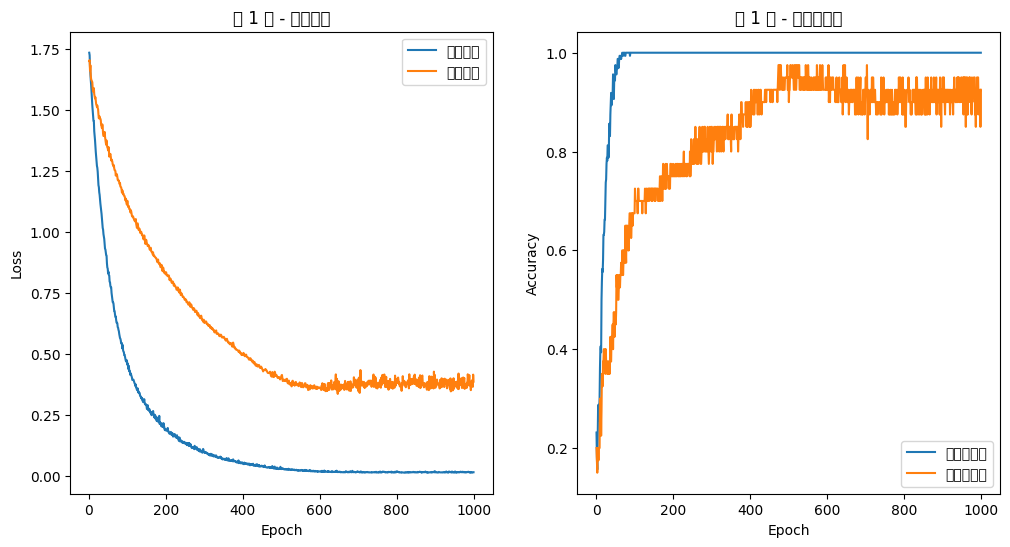


第 2/5 折训练开始
Epoch [1/1000] - 训练损失: 1.6524, 训练准确率: 24.38%
Epoch [1/1000] - 验证损失: 1.7550, 验证准确率: 15.00%
Epoch [2/1000] - 训练损失: 1.6272, 训练准确率: 23.12%
Epoch [2/1000] - 验证损失: 1.8169, 验证准确率: 15.00%
Epoch [3/1000] - 训练损失: 1.5808, 训练准确率: 30.00%
Epoch [3/1000] - 验证损失: 1.6864, 验证准确率: 20.00%
Epoch [4/1000] - 训练损失: 1.5553, 训练准确率: 33.75%
Epoch [4/1000] - 验证损失: 1.6611, 验证准确率: 20.00%
Epoch [5/1000] - 训练损失: 1.5345, 训练准确率: 34.38%
Epoch [5/1000] - 验证损失: 1.6833, 验证准确率: 20.00%
Epoch [6/1000] - 训练损失: 1.5160, 训练准确率: 36.25%
Epoch [6/1000] - 验证损失: 1.6666, 验证准确率: 20.00%
Epoch [7/1000] - 训练损失: 1.4865, 训练准确率: 40.62%
Epoch [7/1000] - 验证损失: 1.6498, 验证准确率: 17.50%
Epoch [8/1000] - 训练损失: 1.4731, 训练准确率: 42.50%
Epoch [8/1000] - 验证损失: 1.6387, 验证准确率: 17.50%
Epoch [9/1000] - 训练损失: 1.4502, 训练准确率: 43.12%
Epoch [9/1000] - 验证损失: 1.6090, 验证准确率: 22.50%
Epoch [10/1000] - 训练损失: 1.4254, 训练准确率: 51.88%
Epoch [10/1000] - 验证损失: 1.6134, 验证准确率: 27.50%
Epoch [11/1000] - 训练损失: 1.3954, 训练准确率: 51.88%
Epoch [11/1000] - 验证损失: 1.6169, 验证准确率: 

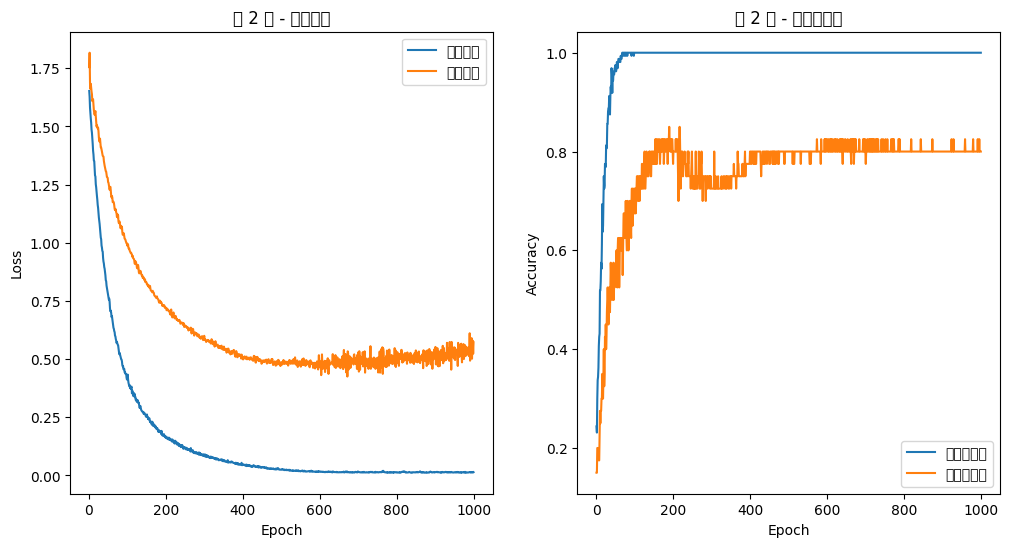


第 3/5 折训练开始
Epoch [1/1000] - 训练损失: 1.7948, 训练准确率: 18.75%
Epoch [1/1000] - 验证损失: 1.7952, 验证准确率: 27.50%
Epoch [2/1000] - 训练损失: 1.6806, 训练准确率: 18.75%
Epoch [2/1000] - 验证损失: 1.8713, 验证准确率: 15.00%
Epoch [3/1000] - 训练损失: 1.6653, 训练准确率: 21.88%
Epoch [3/1000] - 验证损失: 1.7432, 验证准确率: 15.00%
Epoch [4/1000] - 训练损失: 1.6167, 训练准确率: 28.12%
Epoch [4/1000] - 验证损失: 1.6482, 验证准确率: 15.00%
Epoch [5/1000] - 训练损失: 1.6058, 训练准确率: 23.75%
Epoch [5/1000] - 验证损失: 1.6934, 验证准确率: 20.00%
Epoch [6/1000] - 训练损失: 1.5772, 训练准确率: 29.38%
Epoch [6/1000] - 验证损失: 1.7056, 验证准确率: 15.00%
Epoch [7/1000] - 训练损失: 1.5532, 训练准确率: 31.25%
Epoch [7/1000] - 验证损失: 1.6902, 验证准确率: 15.00%
Epoch [8/1000] - 训练损失: 1.5285, 训练准确率: 32.50%
Epoch [8/1000] - 验证损失: 1.7167, 验证准确率: 12.50%
Epoch [9/1000] - 训练损失: 1.5119, 训练准确率: 36.88%
Epoch [9/1000] - 验证损失: 1.7051, 验证准确率: 12.50%
Epoch [10/1000] - 训练损失: 1.4848, 训练准确率: 36.25%
Epoch [10/1000] - 验证损失: 1.6645, 验证准确率: 15.00%
Epoch [11/1000] - 训练损失: 1.4636, 训练准确率: 39.38%
Epoch [11/1000] - 验证损失: 1.6379, 验证准确率: 

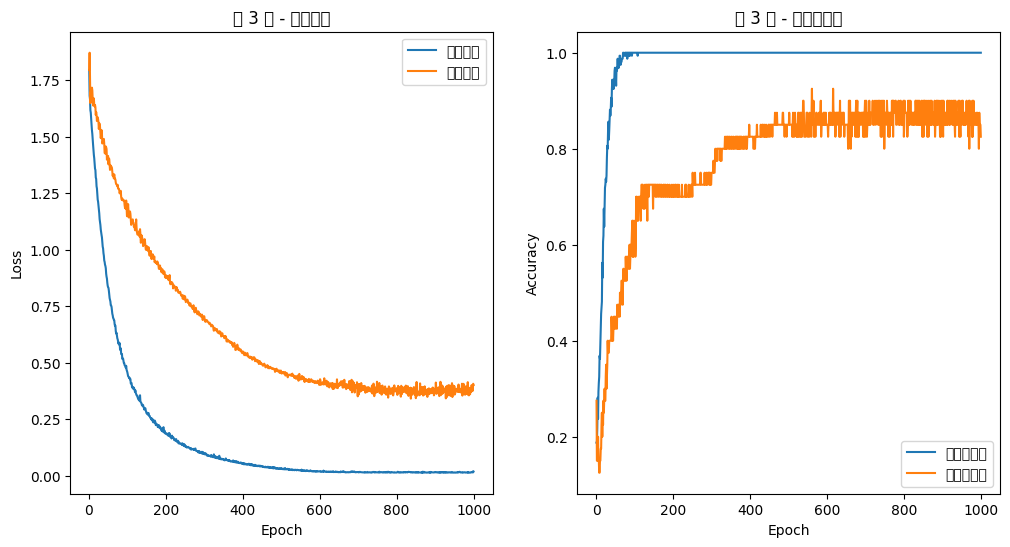


第 4/5 折训练开始
Epoch [1/1000] - 训练损失: 1.7349, 训练准确率: 23.75%
Epoch [1/1000] - 验证损失: 1.7633, 验证准确率: 12.50%
Epoch [2/1000] - 训练损失: 1.5712, 训练准确率: 31.25%
Epoch [2/1000] - 验证损失: 1.8473, 验证准确率: 30.00%
Epoch [3/1000] - 训练损失: 1.5641, 训练准确率: 30.00%
Epoch [3/1000] - 验证损失: 1.7802, 验证准确率: 27.50%
Epoch [4/1000] - 训练损失: 1.5228, 训练准确率: 32.50%
Epoch [4/1000] - 验证损失: 1.6869, 验证准确率: 25.00%
Epoch [5/1000] - 训练损失: 1.5079, 训练准确率: 31.25%
Epoch [5/1000] - 验证损失: 1.6158, 验证准确率: 25.00%
Epoch [6/1000] - 训练损失: 1.4899, 训练准确率: 32.50%
Epoch [6/1000] - 验证损失: 1.6132, 验证准确率: 30.00%
Epoch [7/1000] - 训练损失: 1.4733, 训练准确率: 35.00%
Epoch [7/1000] - 验证损失: 1.6289, 验证准确率: 22.50%
Epoch [8/1000] - 训练损失: 1.4379, 训练准确率: 38.75%
Epoch [8/1000] - 验证损失: 1.5949, 验证准确率: 30.00%
Epoch [9/1000] - 训练损失: 1.4231, 训练准确率: 43.12%
Epoch [9/1000] - 验证损失: 1.5843, 验证准确率: 30.00%
Epoch [10/1000] - 训练损失: 1.4038, 训练准确率: 48.75%
Epoch [10/1000] - 验证损失: 1.5883, 验证准确率: 30.00%
Epoch [11/1000] - 训练损失: 1.3911, 训练准确率: 49.38%
Epoch [11/1000] - 验证损失: 1.5895, 验证准确率: 

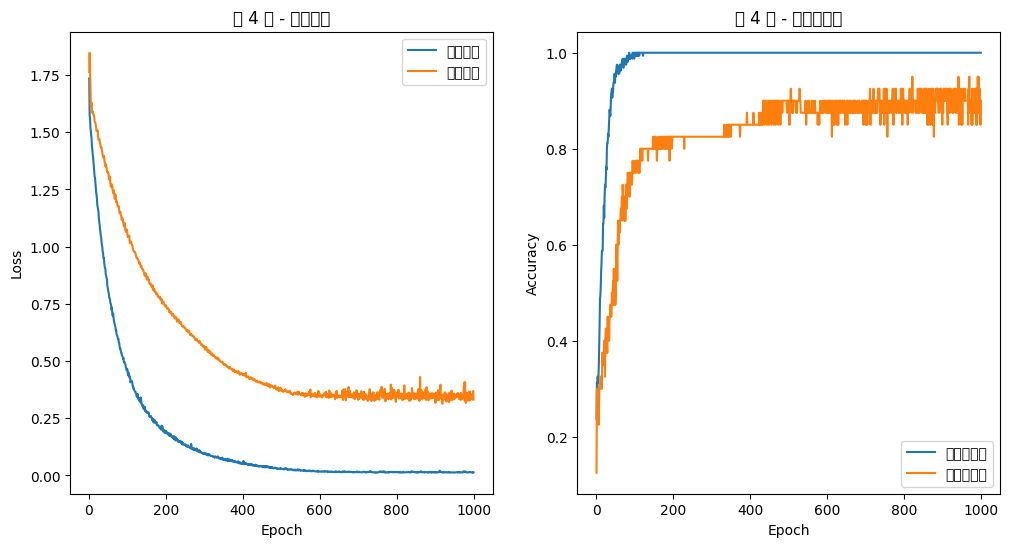


第 5/5 折训练开始
Epoch [1/1000] - 训练损失: 1.7211, 训练准确率: 21.25%
Epoch [1/1000] - 验证损失: 1.9866, 验证准确率: 5.00%
Epoch [2/1000] - 训练损失: 1.6574, 训练准确率: 19.38%
Epoch [2/1000] - 验证损失: 1.9691, 验证准确率: 5.00%
Epoch [3/1000] - 训练损失: 1.6375, 训练准确率: 20.62%
Epoch [3/1000] - 验证损失: 1.8795, 验证准确率: 10.00%
Epoch [4/1000] - 训练损失: 1.5974, 训练准确率: 20.00%
Epoch [4/1000] - 验证损失: 1.7971, 验证准确率: 10.00%
Epoch [5/1000] - 训练损失: 1.5870, 训练准确率: 26.88%
Epoch [5/1000] - 验证损失: 1.6890, 验证准确率: 15.00%
Epoch [6/1000] - 训练损失: 1.5637, 训练准确率: 28.12%
Epoch [6/1000] - 验证损失: 1.6450, 验证准确率: 20.00%
Epoch [7/1000] - 训练损失: 1.5314, 训练准确率: 33.12%
Epoch [7/1000] - 验证损失: 1.6630, 验证准确率: 20.00%
Epoch [8/1000] - 训练损失: 1.5245, 训练准确率: 30.63%
Epoch [8/1000] - 验证损失: 1.6655, 验证准确率: 25.00%
Epoch [9/1000] - 训练损失: 1.4915, 训练准确率: 33.12%
Epoch [9/1000] - 验证损失: 1.6623, 验证准确率: 25.00%
Epoch [10/1000] - 训练损失: 1.4701, 训练准确率: 38.12%
Epoch [10/1000] - 验证损失: 1.6058, 验证准确率: 25.00%
Epoch [11/1000] - 训练损失: 1.4447, 训练准确率: 45.00%
Epoch [11/1000] - 验证损失: 1.5923, 验证准确率: 32

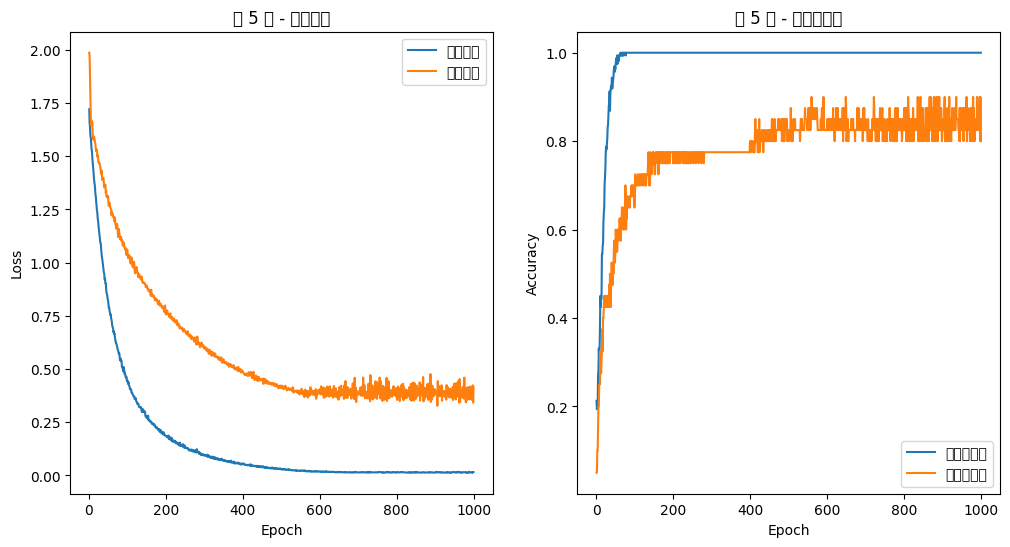


五折交叉验证结果
平均验证准确率: 92.00%
平均验证损失: 0.4541
全局最佳验证准确率: 97.50%
FBCNet模型已保存为：FBCNet_handwriting_model.pth


In [12]:
# 1. 初始化FBCNet模型（查看输入输出维度）
fbcnet_model = FBCNetModel(
    nChan=32,        # 你的数据是32通道
    nTime=1000,      # 250Hz×4s=1000时间点
    nClass=5,        # 5种笔画
    nBands=10,       # 10个频段
    m=16,            # 每个频段32个空间滤波器（FBCNet默认）
    temporalLayer='LogVarLayer',  # 时间聚合：LogVarLayer对数方差  MeanLayer均值聚合
    strideFactor=4   # 时间分块步长（原论文默认）
).to(device)

# 查看模型结构（输入形状：(1,1,32,1000,10) → (batch=1,1,C,T,nBands)）
summary(fbcnet_model, input_size=(1, 32, 1000, 10))


# 2. 训练超参数（与你EEGNet训练参数一致，方便对比）
EPOCHS = 1000
BATCH_SIZE = 32  
LEARNING_RATE = 0.0001
N_splits = 5
Weight_decay = 0.08 # 权重衰减（L2正则化）

# 3. 启动五折交叉验证训练
trainer = TrainModel()  
trained_fbcnet_model = trainer.train_model(
    model_class=FBCNetModel,  # 模型类（FBCNet）
    dataset=train_dataset,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    n_splits=N_splits,
    weight_decay=Weight_decay,
    selection_metric='accuracy'  # 按准确率选择最佳模型
)

# 4. 保存最佳模型
torch.save(trained_fbcnet_model.state_dict(), 'FBCNet_handwriting_model.pth')
print("FBCNet模型已保存为：FBCNet_handwriting_model.pth")



# 评估测试集（session2）的准确率

In [1]:
# 5. 评估测试集（与你原代码一致）
classes_list = ['Heng', 'Shu', 'Pie', 'Dian', 'Zhe']  # 笔画类别
eval_model = EvalModel(trained_fbcnet_model)  
test_accuracy = eval_model.test_model(test_dataset)
eval_model.plot_confusion_matrix(test_dataset, classes_list)

NameError: name 'EvalModel' is not defined